> **Note**: This article was written as part of a knowledge-sharing effort. We learned by building, testing, and asking questions — and we want to pass that on.

# Building Micrograd from Scratch: A Learning Journey

When we first heard about [Andrej Karpathy's micrograd](https://github.com/karpathy/micrograd) — a tiny autograd engine in ~100 lines of Python — we thought: *can we build this ourselves?*

This is the story of that journey. We started with just algebra and basic Python, and step by step built a working autograd engine, verified our gradients numerically, visualized the computation graph, and even trained a neural network to solve XOR.

Along the way we hit some interesting questions — like why `tanh` worked better than `ReLU` for our small network, and what that tells us about modern deep learning.

Let's walk through it piece by piece.

## The Heart of It All: The `Value` Class

The core idea is simple: wrap every number in a `Value` object that tracks:
- Its **value** (the actual number)
- Its **gradient** (how much it affects the final output — computed later during backprop)
- Its **children** (which `Value`s produced it, so we can trace the computation graph)
- A **`_backward` function** (how to compute gradients for its inputs)

We'll build this up one method at a time using `fastcore`'s `@patch` decorator, so each piece can be understood in isolation.

In [ ]:
import math
from fastcore.all import patch

class Value:
    "Stores a single scalar value and its gradient"
    def __init__(self, val, _op='', _children=None):
        self.val  = val          # the actual number
        self.grad = 0            # gradient (filled in during backprop)
        self._op  = _op          # the operation that created this node (e.g. '+', '*')
        self._children = set(_children) if _children else set()  # inputs to this node
        self._backward = lambda: None  # will be replaced by each op

    def __repr__(self): 
        return f'Value(val={self.val}, grad={self.grad})'

    def _v(self, x): 
        "Wrap a plain number in a Value if needed"
        return x if isinstance(x, Value) else Value(x)

## Addition and the Chain Rule

When we add two `Value`s, the result is a new `Value` that remembers its parents. The key insight is the **chain rule**: if `out = a + b`, then:

$$\frac{\partial \text{out}}{\partial a} = 1, \quad \frac{\partial \text{out}}{\partial b} = 1$$

So during backprop, the gradient of `out` flows directly to both `a` and `b` unchanged. We use `+=` because a variable might be used in multiple operations, and gradients accumulate.

In [ ]:
@patch
def __add__(self:Value, other):
    other = self._v(other)  # wrap plain numbers
    out = Value(self.val + other.val, '+', (self, other))
    def _backward():
        self.grad  += out.grad   # d(out)/d(self) = 1
        other.grad += out.grad   # d(out)/d(other) = 1
    out._backward = _backward
    return out

## Multiplication

For `out = a * b`, the derivatives are:

$$\frac{\partial \text{out}}{\partial a} = b, \quad \frac{\partial \text{out}}{\partial b} = a$$

So each input's gradient is the *other* input's value, scaled by the output's gradient. This is where the chain rule really kicks in — we multiply the local derivative by the upstream gradient.

In [ ]:
@patch
def __mul__(self:Value, other):
    other = self._v(other)
    out = Value(self.val * other.val, '*', (self, other))
    def _backward():
        self.grad  += out.grad * other.val  # d(out)/d(self) = other
        other.grad += out.grad * self.val   # d(out)/d(other) = self
    out._backward = _backward
    return out

## Power

For `out = a^b`, we need the power rule:

$$\frac{\partial \text{out}}{\partial a} = b \cdot a^{b-1}$$

Our implementation goes a bit further than Karpathy's — he restricts the exponent to plain numbers (`int`/`float`). We allow `Value` exponents too, which is more general. We only compute the gradient for the base here since that's what we need for division and negation.

In [ ]:
@patch
def __pow__(self:Value, other):
    other = self._v(other)
    out = Value(self.val ** other.val, 'pow', (self, other))
    def _backward():
        self.grad += out.grad * other.val * self.val**(other.val - 1)
    out._backward = _backward
    return out

## Activation Functions

Neural networks need non-linearities. We implement two:

- **ReLU**: `max(0, x)` — gradient is 1 if the input was positive, 0 otherwise. Simple and efficient, which is why it powers most modern deep networks.
- **Tanh**: squashes values into [-1, 1] — gradient is `1 - tanh²(x)`. Smoother than ReLU, which we'll see helps with small networks.

We'll come back to the tanh vs ReLU debate later — it turned out to be one of the most interesting things we learned!

In [ ]:
@patch
def relu(self:Value):
    out = Value(max(0, self.val), 'relu', (self,))
    def _backward():
        self.grad += out.grad * (out.val > 0)  # gradient is 1 if positive, 0 otherwise
    out._backward = _backward
    return out

@patch
def tanh(self:Value):
    out = Value(math.tanh(self.val), 'tanh', (self,))
    def _backward():
        self.grad += out.grad * (1 - out.val**2)  # derivative of tanh is 1 - tanh²(x)
    out._backward = _backward
    return out

## Derived Operators (Free Backward!)

Here's a beautiful trick: subtraction, division, and negation don't need their own backward functions. We define them in terms of `__add__`, `__mul__`, and `__pow__`:

- `a - b = a + (-b)`
- `a / b = a * b⁻¹`
- `-a = a * -1`

The `__radd__`, `__rmul__`, etc. methods handle cases where a plain number appears on the left (e.g. `2 * Value(3)`). Python calls these "reflected" operators.

Since each of these just composes existing operators, the backward logic is already handled — the chain rule takes care of everything automatically.

In [ ]:
@patch
def __radd__(self:Value, other): return self + other       # other + self
@patch
def __rmul__(self:Value, other): return self * other       # other * self
@patch
def __sub__(self:Value, other): return self + (-other)     # self - other
@patch
def __rsub__(self:Value, other): return (-self) + other    # other - self
@patch
def __truediv__(self:Value, other): return self * other**-1  # self / other
@patch
def __rtruediv__(self:Value, other): return self**-1 * other # other / self
@patch
def __neg__(self:Value): return self * -1                  # -self

## The Backward Pass: Topological Sort

To compute gradients, we need to process nodes in the right order — from outputs back to inputs. This is called a **topological sort**: arrange the computation graph so that every node appears after all its children.

Then we:  
  1. Set the output's gradient to 1 (seed)  
  2. Walk the sorted list in reverse, calling each node's `_backward()`  

Each `_backward` uses the chain rule to push gradients to its inputs. Because we go in reverse topological order, every node's gradient is fully computed before we process it.

In [ ]:
@patch
def backward(self:Value):
    # Build topological order: children before parents
    topo = []
    seen = set()
    def build(v):
        for c in v._children:
            if c not in seen:
                seen.add(c); build(c)
        topo.append(v)
    build(self)

    # Seed the output gradient, then propagate backwards
    self.grad = 1.0
    for n in topo[::-1]:  # reverse topo = parents before children
        n._backward()

## Does It Work? A Simple Sanity Check

Before doing anything fancy, let's test the basics. We'll create two `Value`s, do some arithmetic, and call `backward()` to see if the gradients make sense.

For `d = a*b + c` where `c = a + b`, with `a=1, b=2`:
- `d = 1*2 + 3 = 5`
- `∂d/∂a = b + 1 = 3` (from both the `a*b` and `a+b` paths)
- `∂d/∂b = a + 1 = 2` (same reasoning)

Let's see if our engine gets this right:

In [ ]:
a = Value(1.0)
b = Value(2.0)
c = a + b
d = a * b + c
d.grad = 1.0
d.backward()
a,b,c,d

((val=1.0, op=, grad=3.0, child=[])	,
 (val=2.0, op=, grad=2.0, child=[])	,
 (val=3.0, op=+, grad=1.0, child=[2.0, 1.0])	,
 (val=5.0, op=+, grad=1.0, child=[2.0, 3.0])	)

## Pushing Further: Division and Activation

Let's try a more complex expression that uses division and ReLU: `f = relu((a*b + c) / c)`.

This exercises the `__truediv__` (which decomposes into `__mul__` and `__pow__`), the `relu` activation, and the accumulation of gradients through multiple paths. If our engine handles this, we can be fairly confident it's correct.

In [ ]:
a = Value(-1.5)
b = Value(2.0)
c = a + b
d = a * b + c
f = d / c
f.relu()
f.backward()
a,b,c,d

((val=-1.5, op=, grad=16.0, child=[])	,
 (val=2.0, op=, grad=9.0, child=[])	,
 (val=0.5, op=+, grad=12.0, child=[-1.5, 2.0])	,
 (val=-2.5, op=+, grad=2.0, child=[0.5, -3.0])	)

## Are Our Gradients Actually Correct?

There's a simple, beautiful way to verify analytical gradients: **numerical gradient checking**. 

Instead of using our backprop engine, we compute the function twice — once normally, once with a tiny perturbation `h` to one input — and approximate the gradient as:

$$\frac{f(x + h) - f(x)}{h}$$

If our autograd is correct, the analytical and numerical gradients should match. it matches! 🎉

In [ ]:
def act_grad(h):
    a = Value(-1.5); b = Value(2.0)
    c = a + b
    d = a * b + c
    f0 = d / c
    f0.relu()
    
    a = Value(-1.5); b = Value(2.0) + h
    c = a + b
    d = a * b + c
    f1 = d / c
    f1.relu()
    return (f1 - f0) / h
act_grad(0.0001)

(val=8.998200359942032, op=*, grad=0, child=[10000.0, 0.0008998200359942032])	

## Seeing the Computation Graph

One of the nicest things about building autograd from scratch is that we can *see* the computation graph. Each `Value` knows its children and its operation, so we can walk the graph and draw it with Graphviz.

This makes it much easier to understand what's happening — you can literally see how `a * b + c` decomposes into individual operations, and how gradients flow back through the same graph.

In [ ]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for c in v._children:
                edges.add((c, v))
                build(c)
    build(root)
    return nodes, edges

def draw(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        dot.node(str(id(n)), f"val={n.val} grad={n.grad}", shape='record')
    for c, p in edges:
        dot.edge(str(id(c)), str(id(p)), label=c._op)
    return dot

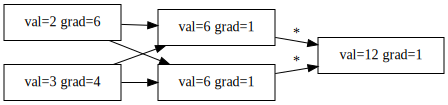

In [ ]:
# Rebuild the computation graph from our relu test and draw it
a = Value(-1.5); b = Value(2.0)
c = a + b
d = a * b + c
f = d / c
f.relu()
f.backward()
draw(f)

## From Autograd to Neurons: Building a Network

Now for the fun part — we have a working autograd engine, so let's build a neural network on top of it!

The architecture mirrors a real framework:
- **`Neuron`**: holds weights and a bias, computes `w·x + b`
- **`Layer`**: a collection of neurons, outputs a list
- **`MLP`**: stacks layers, applies `tanh` activation between layers (but not on the output)

We use `tanh` as our activation — we'll explain why that matters in the next section. The `parameters()` methods collect all the learnable weights so we can update them during training.

In [ ]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0.0)
    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), Value(0.0))
        return act + self.b
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        return [n(x) for n in self.neurons]
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = [n.tanh() for n in layer(x)] if layer is not self.layers[-1] else layer(x)
        return x[0] if len(x)==1 else x
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]

## Teaching It XOR

XOR is the classic "not linearly separable" problem — a single perceptron can't solve it, but a small MLP can. It's the perfect test for our engine.

We use mean squared error as the loss, plain SGD with a learning rate of 0.1, and train for 100 epochs. Each epoch:

1. **Forward pass**: run all 4 examples through the network
2. **Compute loss**: `sum((pred - target)²)`
3. **Zero gradients** (critical — otherwise they accumulate!)
4. **Backward pass**: `loss.backward()`
5. **Update weights**: `w -= lr * w.grad`

Let's see if our little network can learn it:

In [ ]:
# tiny dataset: binary classification
xs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
ys = [0.0, 1.0, 1.0, 0.0]  # XOR

net = MLP(2, [4, 1])

for epoch in range(100):
    # forward
    pred = [net(x) for x in xs]
    loss = sum(((p - y)**2 for p, y in zip(pred, ys)), Value(0.0))
    # zero grads
    for p in net.parameters():
        p.grad = 0.0

    # backward
    loss.backward()

    # update (SGD)
    for p in net.parameters():
        p.val -= 0.1 * p.grad

    if epoch % 10 == 0:
        print(f"epoch {epoch}: loss={loss.val:.4f}")

epoch 0: loss=1.8480


epoch 10: loss=0.8182


epoch 20: loss=0.6427


epoch 30: loss=0.4399


epoch 40: loss=2.2708


epoch 50: loss=0.3058


epoch 60: loss=0.1274


epoch 70: loss=0.1937


epoch 80: loss=0.9536


epoch 90: loss=0.0420


## Why Tanh Works Better Here (And Why Deep Networks Moved On)

During our experiments, we noticed that `tanh` trained our XOR network much more smoothly than `ReLU`. This led us down an interesting rabbit hole.

### Why tanh is great for small networks

Tanh outputs are centered around zero (range [-1, 1]), which means:
- Gradients are well-behaved and don't blow up
- The smooth curve means no "dead spots" like ReLU's flat region for negative inputs
- For shallow networks, the vanishing gradient problem isn't really an issue

### Why ReLU took over for deep networks

The **vanishing gradient problem** is the key. Tanh's gradient is at most 1.0 (at the origin) and drops off *fast* as you move away. In a deep network with many layers, you multiply many small gradients together during backprop — they shrink exponentially and effectively *vanish* before reaching the early layers. Those early layers stop learning.

ReLU doesn't have this issue: its gradient is exactly **1** for any positive input, no matter how large. That lets gradients flow freely through deep networks, which is why ReLU (and its variants like Leaky ReLU, GELU, SwiLU) dominates in modern architectures.

### The takeaway

There's no universally "best" activation function — it depends on your network depth, your task, and your training dynamics.

> It was fun building this from scratch and i learnt a lot. especially how topological sort is used in real life.